# E-commerce Dataset Preprocessing Tutorial


## 🎯 Objective
In this tutorial, we'll cover the **entire data preprocessing pipeline** for the Titanic dataset, including:

- **Data Cleaning**
- **Data Transformation**
- **Data Encoding** (Multiple Techniques)
- **Data Scaling** (All Major Methods with Comparison)

We will also conclude with **best practices** and **recommendations**.

Each section includes **why it's needed**, and **before-and-after transformations** to give a clear, instructional overview.

## 📦 1. Load E-commerce Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Load Marketing Campaign dataset
df = pd.read_csv('test.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6000, 16)


,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value
0,18001,2010-11-14 13:39:00,North,Social Media,Storage,Premium,16.50,1.65,0.2763,845.0,16185,0.0637,6.32,0.366025,30.0,4500.10
1,18002,2010-10-10 11:53:00,North,Affiliate,Storage,Premium,15.00,1.25,0.1694,525.0,5684,0.0213,2.75,-0.366025,21.0,15.00
2,18003,2010-10-31 11:06:00,North,Social Media,General,Premium,325.44,3.39,0.3736,362.0,11490,0.0070,0.58,-0.366025,NaN,1818.31
3,18004,2011-02-07 14:51:00,South,Social Media,General,Premium,7.80,0.65,0.3246,138.0,3046,0.0686,1.50,1.366025,7.0,4442.36
4,18005,2011-05-16 14:24:00,north,Search,General,Premium,458.00,4.58,0.2625,309.0,8983,0.0231,9.19,-0.366025,28.0,400409.80


## 🧹 2. Data Cleaning
Cleaning ensures our dataset is usable and free of inconsistencies.

### 2.1 Check for Missing Values
**Why:** Missing data can lead to biased models and unexpected errors.

In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       6000 non-null   int64  
 1   date                     6000 non-null   object 
 2   region                   6000 non-null   object 
 3   channel                  6000 non-null   object 
 4   product_category         6000 non-null   object 
 5   customer_segment         6000 non-null   object 
 6   ad_spend                 5771 non-null   float64
 7   price                    6000 non-null   float64
 8   discount_rate            5720 non-null   float64
 9   market_reach             5765 non-null   float64
 10  impressions              6000 non-null   int64  
 11  click_through_rate       5738 non-null   float64
 12  competition_index        5754 non-null   float64
 13  seasonality_index        6000 non-null   float64
 14  campaign_duration_days  

id                           0
date                         0
region                       0
channel                      0
product_category             0
customer_segment             0
ad_spend                   229
price                        0
discount_rate              280
market_reach               235
impressions                  0
click_through_rate         262
competition_index          246
seasonality_index            0
campaign_duration_days     449
customer_lifetime_value    265
dtype: int64

### 2.2 Drop Columns with Too Many Missing Values
**Why:** Columns like 'Cabin' often have over 75% missing values, offering low value.

In [4]:
missing_percentage = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_percentage[missing_percentage > 50].index.tolist()
print(f"Dropping columns with >50% missing: {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

Dropping columns with >50% missing: []


### 2.3 Fill Missing Values
**Why:** Models cannot process `NaN`s — we must impute or drop them.

Fill missing values for numeric columns with median

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

Fill missing values for categorical columns with mode

In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown')


### 2.4 Remove Duplicates (if any)
**Why:** Duplicate rows can distort analysis and model training.

In [7]:
df.drop_duplicates(inplace=True)

print(f"\nData shape after cleaning: {df.shape}")


Data shape after cleaning: (6000, 16)


## 🔄 3. Data Transformation
Transformation improves model performance and interprets data better.


# 3.0 Convert date column to datetime and extract features


In [8]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

Drop original date column

In [9]:
df.drop('date', axis=1, inplace=True)


## 3.1 Binning (Discretization)
**Why:** Binning simplifies continuous data and can capture non-linearity.


In [14]:
bins = [0, 50, 200, 500, float('inf')]
labels = ['Low', 'Medium', 'High', 'Very High']
df['ad_spend_category'] = pd.cut(df['ad_spend'], bins=bins, labels=labels)

# Display both original and new column 
df[['ad_spend', 'ad_spend_category']].head()

,ad_spend,ad_spend_category
0,16.50,Low
1,15.00,Low
2,325.44,High
3,7.80,Low
4,458.00,High


# Create bins for customer_lifetime_value

In [15]:
clv_bins = [0, 1000, 5000, 10000, float('inf')]
clv_labels = ['Low Value', 'Medium Value', 'High Value', 'Premium']
df['clv_category'] = pd.cut(df['customer_lifetime_value'], bins=clv_bins, labels=clv_labels)

df[['ad_spend', 'ad_spend_category', 'customer_lifetime_value', 'clv_category']].head()

,ad_spend,ad_spend_category,customer_lifetime_value,clv_category
0,16.50,Low,4500.10,Medium Value
1,15.00,Low,15.00,Low Value
2,325.44,High,1818.31,Medium Value
3,7.80,Low,4442.36,Medium Value
4,458.00,High,400409.80,Premium


### 3.2 Log Transformation

**Why:** Logarithmic transformation is commonly used to reduce right-skewness in distributions such as income, prices, or in this case, the `Fare` feature from the Titanic dataset.  
Highly skewed features can negatively impact the performance of machine learning algorithms that assume normality (e.g., linear models).

Let’s visualize and measure the effect on skewness.

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Apply log1p to 'ad_spend' (adding 1 to handle zeros)
df['log_ad_spend'] = np.log1p(df['ad_spend'])

# Calculate skewness before and after
original_skew = skew(df['ad_spend'].dropna())
log_skew = skew(df['log_ad_spend'].dropna())

print(f"Original Skewness (ad_spend): {original_skew:.2f}")
print(f"Log-Transformed Skewness (log_ad_spend): {log_skew:.2f}")

Original Skewness (ad_spend): 7.80
Log-Transformed Skewness (log_ad_spend): 1.18


Apply log transformation to other skewed features

In [18]:
df['log_price'] = np.log1p(df['price'])
df['log_impressions'] = np.log1p(df['impressions'].clip(lower=0))  # Handle negative values
df['log_market_reach'] = np.log1p(df['market_reach'])

df[['ad_spend', 'log_ad_spend', 'price', 'log_price']].head()


,ad_spend,log_ad_spend,price,log_price
0,16.50,2.862201,1.65,0.974560
1,15.00,2.772589,1.25,0.810930
2,325.44,5.788246,3.39,1.479329
3,7.80,2.174752,0.65,0.500775
4,458.00,6.129050,4.58,1.719189


Visualize log transformation effect

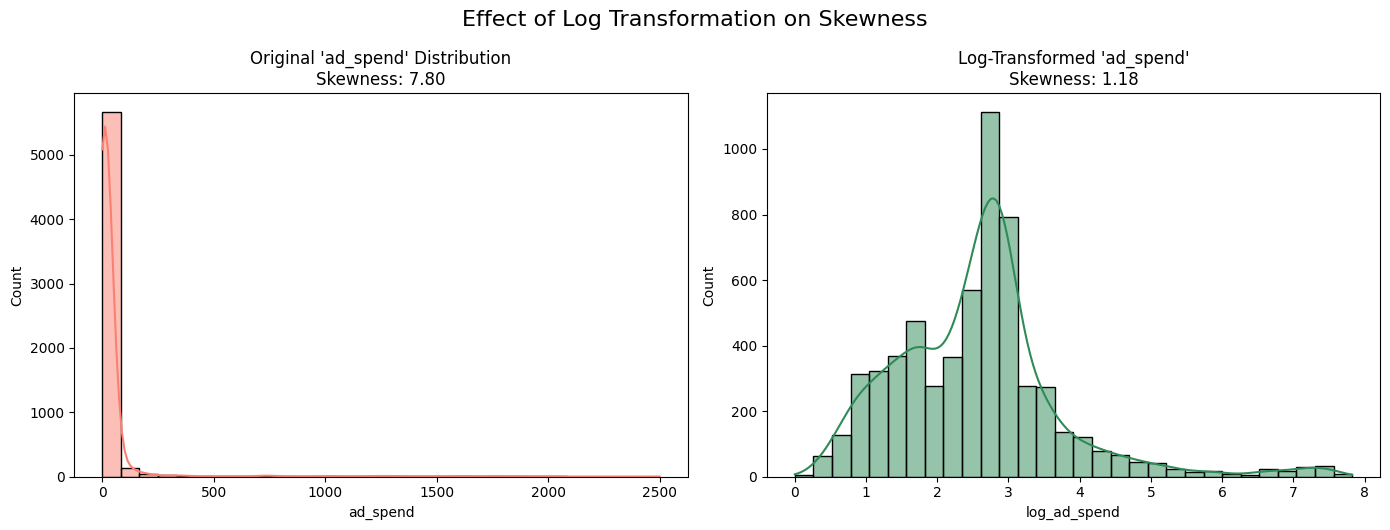

In [19]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['ad_spend'], kde=True, bins=30, color='salmon')
plt.title(f"Original 'ad_spend' Distribution\nSkewness: {original_skew:.2f}")

plt.subplot(1, 2, 2)
sns.histplot(df['log_ad_spend'], kde=True, bins=30, color='seagreen')
plt.title(f"Log-Transformed 'ad_spend'\nSkewness: {log_skew:.2f}")

plt.tight_layout()
plt.suptitle("Effect of Log Transformation on Skewness", fontsize=16, y=1.05)
plt.show()


### 3.3 Feature Engineering
**Why:** Creating features like 'FamilySize' adds predictive value.

In [20]:
# Calculate click_through_rate from missing values (if needed)
# Fill missing click_through_rate with median
df['click_through_rate'] = df['click_through_rate'].fillna(df['click_through_rate'].median())

# Create engagement score
df['engagement_score'] = df['impressions'] * df['click_through_rate']

# Create ROI metric 
df['roi_estimate'] = (df['impressions'] * df['click_through_rate'] * 0.01) / (df['ad_spend'] + 1)

# Create interaction features
df['price_discount_interaction'] = df['price'] * (1 - df['discount_rate'])
df['competition_seasonality'] = df['competition_index'] * df['seasonality_index']

# Campaign efficiency metrics
df['impressions_per_dollar'] = df['impressions'] / (df['ad_spend'] + 1)
df['reach_per_dollar'] = df['market_reach'] / (df['ad_spend'] + 1)

df[['ad_spend', 'impressions', 'engagement_score', 'roi_estimate', 'impressions_per_dollar']].head()

,ad_spend,impressions,engagement_score,roi_estimate,impressions_per_dollar
0,16.50,16185,1030.9845,0.589134,924.857143
1,15.00,5684,121.0692,0.075668,355.250000
2,325.44,11490,80.4300,0.002464,35.197892
3,7.80,3046,208.9556,0.237450,346.136364
4,458.00,8983,207.5073,0.004521,19.570806


### 3.4 Clean Categorical Columns
**Why:** 'Title' correlates with age, gender, and social status.

In [31]:
# Clean columns
df['region'] = df['region'].str.strip().str.title()
df['channel'] = df['channel'].str.strip().str.title()
df['channel'] = df['channel'].str.replace('_', ' ').str.replace('Socail', 'Social')
df['channel'] = df['channel'].str.replace('Tv', 'TV')

# Create clean table
print("\n" + "="*90)
print(" CATEGORICAL COLUMNS SUMMARY")
print("="*90)

print(f"{'Column':<20} {'Unique Count':<15} {'Unique Values'}")
print("-"*90)

# Region
regions = ', '.join(sorted(df['region'].unique()))
print(f"{'Region':<20} {df['region'].nunique():<15} {regions}")

# Channel
channels = ', '.join(sorted(df['channel'].unique()))
print(f"{'Channel':<20} {df['channel'].nunique():<15} {channels}")

# Product Category
products = ', '.join(sorted(df['product_category'].unique()))
print(f"{'Product Category':<20} {df['product_category'].nunique():<15} {products}")

# Customer Segment
segments = ', '.join(sorted(df['customer_segment'].unique()))
print(f"{'Customer Segment':<20} {df['customer_segment'].nunique():<15} {segments}")

print("="*90)


 CATEGORICAL COLUMNS SUMMARY
Column               Unique Count    Unique Values
------------------------------------------------------------------------------------------
Region               7               Central, East, Norht, Nort, North, South, West
Channel              7               Affiliate, Email, Influencer, Search, Social Media, Socialmedia, TV
Product Category     6               General, Kitchen, Lighting, Seasonal, Stationery, Storage
Customer Segment     3               Budget, Premium, Standard


## 🧮 4. Data Encoding
Encoding converts categorical variables into numerical formats suitable for ML.

### 4.1 Label Encoding (For Ordinal Features)
**Before:** `Sex` → ['male', 'female']

**After:** `Sex_encoded` → [1, 0]

In [32]:
from sklearn.preprocessing import LabelEncoder
segment_order = {'Budget': 0, 'Standard': 1, 'Premium': 2}
df['customer_segment_encoded'] = df['customer_segment'].map(segment_order)

df[['customer_segment', 'customer_segment_encoded']].head()


,customer_segment,customer_segment_encoded
0,Premium,2
1,Premium,2
2,Premium,2
3,Premium,2
4,Premium,2


### 4.2 One-Hot Encoding (For Nominal Features)
**Before:** `Embarked` → C, Q, S

**After:** `Embarked_Q`, `Embarked_S`

In [ ]:
df = pd.get_dummies(df, columns=['channel', 'region', 'product_category'], 
                     prefix=['channel', 'region', 'category'], drop_first=True)

print("Shape after one-hot encoding:", df.shape)

Shape after one-hot encoding: (6000, 46)


In [35]:
df.head(3)

,id,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,...,region_Norht,region_Nort,region_North,region_South,region_West,category_Kitchen,category_Lighting,category_Seasonal,category_Stationery,category_Storage
0,18001,Premium,16.50,1.65,0.2763,845.0,16185,0.0637,6.32,0.366025,...,False,False,True,False,False,False,False,False,False,True
1,18002,Premium,15.00,1.25,0.1694,525.0,5684,0.0213,2.75,-0.366025,...,False,False,True,False,False,False,False,False,False,True
2,18003,Premium,325.44,3.39,0.3736,362.0,11490,0.0070,0.58,-0.366025,...,False,False,True,False,False,False,False,False,False,False


### 4.3 Ordinal Encoding (For Ordered Categories)
**Before:** AgeGroup → ['Child', 'Teen', 'Adult', 'Senior']

**After:** AgeGroup_Ordinal → [0, 1, 2, 3]

In [36]:
ad_spend_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
df['ad_spend_category_ordinal'] = df['ad_spend_category'].map(ad_spend_order)

# Create clv_category ordinal
clv_order = {'Low Value': 0, 'Medium Value': 1, 'High Value': 2, 'Premium': 3}
df['clv_category_ordinal'] = df['clv_category'].map(clv_order)

df[['ad_spend_category', 'ad_spend_category_ordinal', 'clv_category', 'clv_category_ordinal']].head()

,ad_spend_category,ad_spend_category_ordinal,clv_category,clv_category_ordinal
0,Low,0,Medium Value,1
1,Low,0,Low Value,0
2,High,2,Medium Value,1
3,Low,0,Medium Value,1
4,High,2,Premium,3


### 4.4 Binary Encoding (For High-Cardinality Columns)
**Why:** Reduces dimensionality vs. one-hot encoding.
> Install `category_encoders` if you'd like to try:
```bash
pip install category-encoders
```

## 📏 5. Data Scaling
Scaling is essential when features differ in range — especially for distance-based models.

### 5.1 Min-Max Scaling
**Range:** [0, 1]

In [37]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['ad_spend_minmax'] = scaler.fit_transform(df[['ad_spend']])
df[['ad_spend', 'ad_spend_minmax']].head()


,ad_spend,ad_spend_minmax
0,16.50,0.006600
1,15.00,0.006000
2,325.44,0.130176
3,7.80,0.003120
4,458.00,0.183200


### 5.2 Standardization (Z-score)
**Mean = 0, Std = 1**

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['ad_spend_std'] = scaler.fit_transform(df[['ad_spend']])
df[['ad_spend', 'ad_spend_std']].head()

,ad_spend,ad_spend_std
0,16.50,-0.146432
1,15.00,-0.154518
2,325.44,1.519049
3,7.80,-0.193333
4,458.00,2.233674


### 5.3 Robust Scaling
**Why:** Handles outliers by using median and IQR.

In [39]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df['ad_spend_robust'] = scaler.fit_transform(df[['ad_spend']])
df[['ad_spend', 'ad_spend_robust']].head()

,ad_spend,ad_spend_robust
0,16.50,0.263025
1,15.00,0.161861
2,325.44,21.098634
3,7.80,-0.323723
4,458.00,30.038779


### 5.4 MaxAbs Scaling
**Preserves sparsity and scale sign.**

In [40]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
df['ad_spend_maxabs'] = scaler.fit_transform(df[['ad_spend']])
df[['ad_spend', 'ad_spend_maxabs']].head()

,ad_spend,ad_spend_maxabs
0,16.50,0.006600
1,15.00,0.006000
2,325.44,0.130176
3,7.80,0.003120
4,458.00,0.183200


### 🎯 Target Columns to Scale
```python
cols_to_scale = ['age', 'fare']
```

### 🧮 Different Scalers

In [42]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler

# Select columns to scale (numeric columns)
cols_to_scale = ['ad_spend', 'price', 'discount_rate', 'market_reach', 
                 'impressions', 'click_through_rate', 'competition_index', 
                 'seasonality_index', 'campaign_duration_days', 'customer_lifetime_value']

# Ensure columns exist
cols_to_scale = [col for col in cols_to_scale if col in df.columns]

scalers = {
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
    "Robust": RobustScaler(),
    "MaxAbs": MaxAbsScaler()
}

scaled_data = {}

for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df[cols_to_scale])
    scaled_df = pd.DataFrame(scaled, columns=[f'{col}_{name}' for col in cols_to_scale])
    scaled_data[name] = scaled_df
    df = pd.concat([df, scaled_df], axis=1)

print("Columns after scaling:", df.columns.tolist()[:10], "...")

Columns after scaling: ['id', 'customer_segment', 'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'seasonality_index'] ...


### 📊 Visual Comparison of Scaling Methods

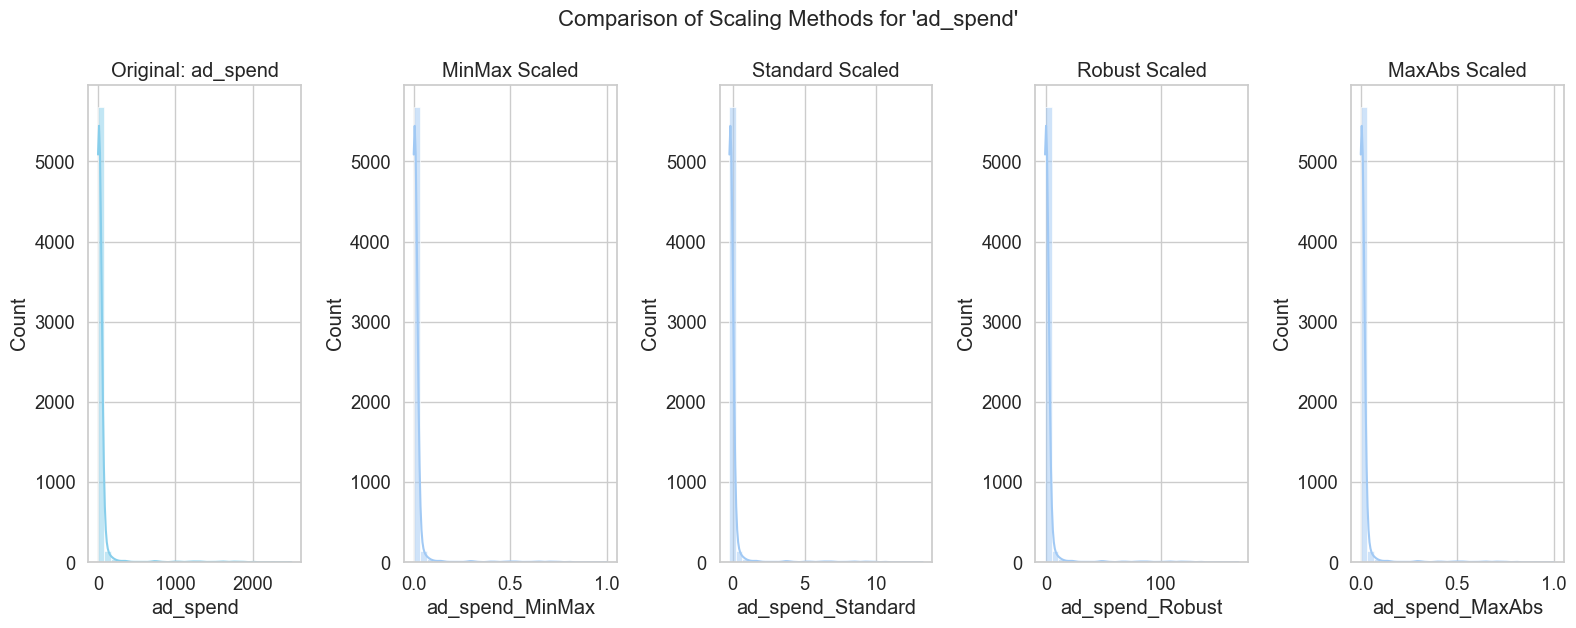

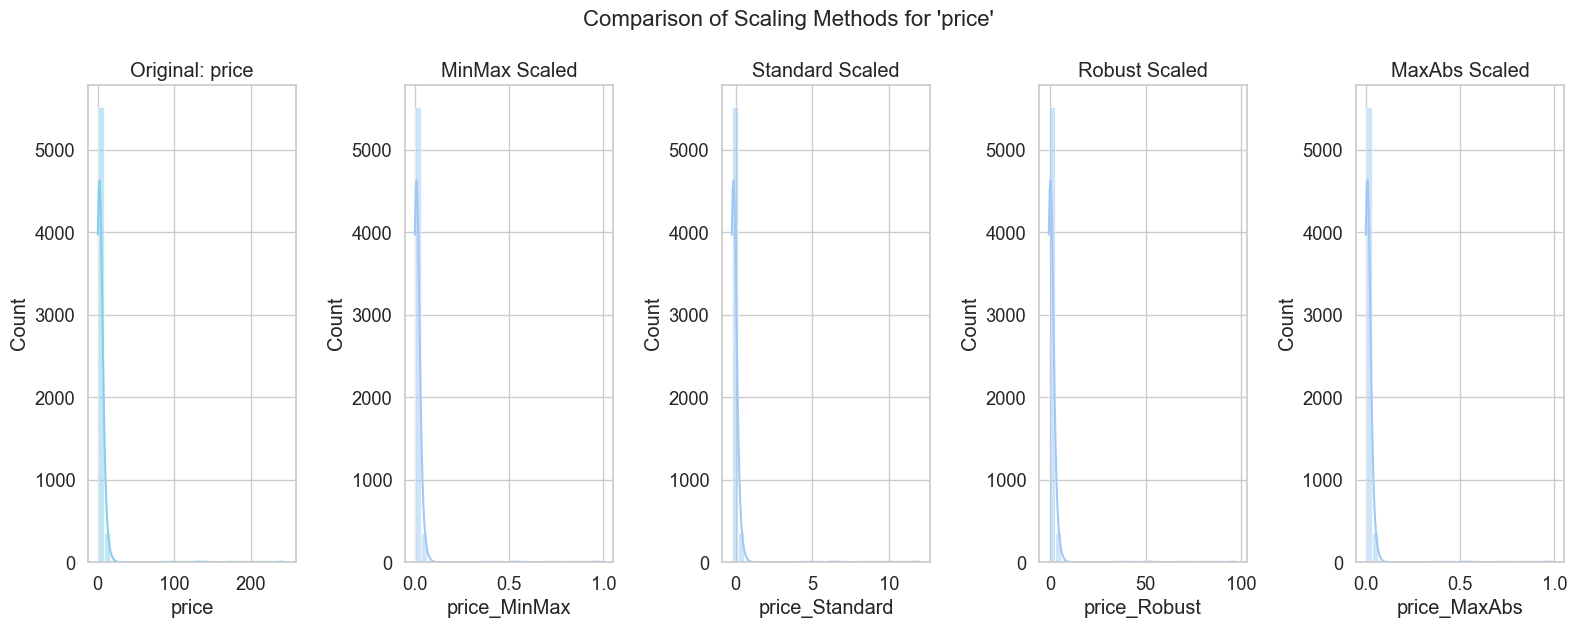

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up Seaborn styling
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

# Plotting before and after scaling for each scaler
for col in cols_to_scale[:2]:  # Show first 2 features for brevity
    plt.figure(figsize=(16, 6))

    # Original distribution
    plt.subplot(1, len(scalers) + 1, 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f"Original: {col}")

    # Scaled distributions
    for i, scaler_name in enumerate(scalers.keys(), start=2):
        plt.subplot(1, len(scalers) + 1, i)
        sns.histplot(df[f"{col}_{scaler_name}"], kde=True, bins=30)
        plt.title(f"{scaler_name} Scaled")

    plt.tight_layout()
    plt.suptitle(f"Comparison of Scaling Methods for '{col}'", fontsize=16, y=1.05)
    plt.show()


## ✅ Summary & Best Practices

### 🔹 Why Do This?
- Cleaning removes inconsistencies and gaps.
- Transformation enhances feature relevance.
- Encoding enables ML algorithms to understand categorical values.
- Scaling makes model optimization smoother and more stable.

### 🔹 Recommendations
- Use **StandardScaler** for most models.
- Use **RobustScaler** if outliers dominate.
- Choose **One-Hot** for nominal and **Ordinal** for ordered categorical variables.
- Use **log transformation** for skewed numeric features.

### Final Dataset Overview

In [44]:
print(f"Final dataset shape: {df.shape}")
print(f"Final columns: {df.columns.tolist()}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

# Save preprocessed data
df.to_csv('marketing_campaign_preprocessed.csv', index=False)
print("Preprocessed data saved to 'marketing_campaign_preprocessed.csv'")

Final dataset shape: (6000, 92)
Final columns: ['id', 'customer_segment', 'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'seasonality_index', 'campaign_duration_days', 'customer_lifetime_value', 'year', 'month', 'day', 'dayofweek', 'ad_spend_category', 'clv_category', 'log_ad_spend', 'log_price', 'log_impressions', 'log_market_reach', 'engagement_score', 'roi_estimate', 'price_discount_interaction', 'competition_seasonality', 'impressions_per_dollar', 'reach_per_dollar', 'customer_segment_encoded', 'channel_Email', 'channel_Influencer', 'channel_Search', 'channel_Social Media', 'channel_Socialmedia', 'channel_TV', 'region_East', 'region_Norht', 'region_Nort', 'region_North', 'region_South', 'region_West', 'category_Kitchen', 'category_Lighting', 'category_Seasonal', 'category_Stationery', 'category_Storage', 'ad_spend_category_ordinal', 'clv_category_ordinal', 'ad_spend_minmax', 'ad_spend_std', 'ad_spend_robust', 'ad_spen